In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb

1.

In [ ]:
import seaborn as sns

2.

In [ ]:
car_df = pd.read_csv('1_used_car_prices.csv')

In [ ]:
car_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   brand                961 non-null    object 
 1   age_years            974 non-null    float64
 2   mileage_km           970 non-null    float64
 3   engine_type          979 non-null    object 
 4   engine_size_cc       970 non-null    float64
 5   horsepower           979 non-null    float64
 6   fuel_efficiency_kml  974 non-null    float64
 7   accident_count       972 non-null    float64
 8   color                968 non-null    object 
 9   option_grade         973 non-null    object 
 10  price_krw            1000 non-null   float64
dtypes: float64(7), object(4)
memory usage: 86.1+ KB


In [ ]:
답안01 = 'color'

3.

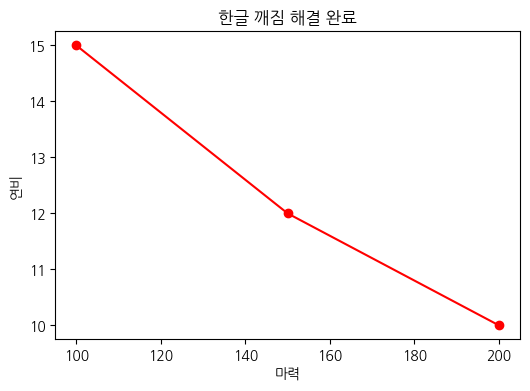

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import urllib.request

# 1. 인터넷에서 나눔고딕 폰트 파일을 현재 폴더로 직접 다운로드
font_url = "https://github.com/google/fonts/raw/main/ofl/nanumgothic/NanumGothic-Regular.ttf"
urllib.request.urlretrieve(font_url, "my_nanum_font.ttf")

# 2. 다운로드한 폰트 파일의 경로 지정 및 이름 속성 가져오기
fe = fm.FontEntry(fname="my_nanum_font.ttf", name="MyNanum")
fm.fontManager.ttflist.insert(0, fe)  # Matplotlib 폰트 리스트 맨 앞에 강제 주입

# 3. 주입한 폰트 이름으로 전역 설정 변경 (마이너스 깨짐 방지도 함께)
plt.rc('font', family='MyNanum')
plt.rcParams['axes.unicode_minus'] = False

# ----------------------------------------------------
# 4. [확인용] 실제 그리시려던 마력/연비 그래프 코드를 여기에 실행해 보세요!
plt.figure(figsize=(6, 4))
plt.plot([100, 150, 200], [15, 12, 10], 'ro-') # 예시 데이터

plt.xlabel('마력')
plt.ylabel('연비')
plt.title('한글 깨짐 해결 완료')
plt.show()

<Axes: xlabel='engine_type', ylabel='price_krw'>

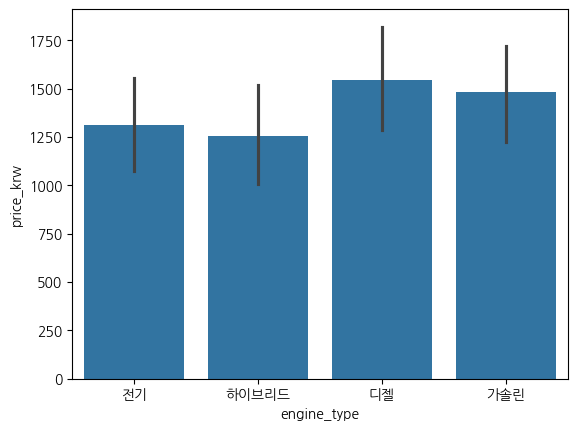

In [ ]:
sns.barplot(data=car_df, x='engine_type', y='price_krw')

In [ ]:
답안03='디젤'

4.

In [ ]:
car_df.groupby(['brand', 'option_grade'])['price_krw'].mean()

brand  option_grade
A사     고급              1261.629630
       기본              1188.489583
       중급              1314.852632
B사     고급              1539.666667
       기본              1503.191489
       중급              1877.250000
C사     고급              1165.759259
       기본              1924.813559
       중급              1316.819672
D사     고급              1467.735849
       기본              1218.375000
       중급              1019.464286
Name: price_krw, dtype: float64

In [ ]:
답안04='C사, 중급'

5.

In [ ]:
car_pre = car_df.copy()

car_pre['option_grade'].fillna(car_pre['option_grade'].mode()[0], inplace=True)
car_pre.drop(columns=['color'], inplace=True)

/tmp/ipykernel_1439/882445906.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  car_pre['option_grade'].fillna(car_pre['option_grade'].mode()[0], inplace=True)


6.

In [ ]:
car_pre['brand'].fillna('unknown', inplace=True)

categorical_cols = ['brand', 'engine_type', 'option_grade']

car_numeric = pd.get_dummies(data=car_pre, columns=categorical_cols)

/tmp/ipykernel_1439/1324908915.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  car_pre['brand'].fillna('unknown', inplace=True)


7.

In [ ]:
# 아래 코드를 실행하세요.
corr_cols = ['age_years', 'mileage_km', 'engine_size_cc', 'horsepower', 'fuel_efficiency_kml', 'price_krw']
plt.figure(figsize=(10, 8))

<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

<Axes: >

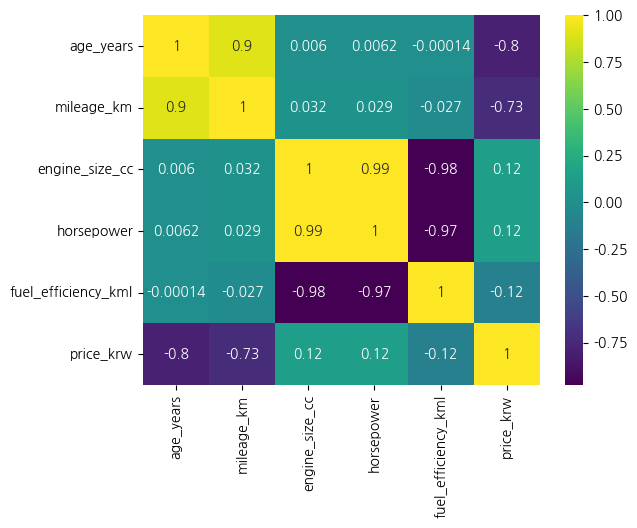

In [ ]:
sns.heatmap(data=car_numeric[corr_cols].corr(), annot=True, cmap='viridis')

In [ ]:
답안07 = 3

8.

In [ ]:
from sklearn.model_selection import train_test_split

X = car_numeric.drop(columns=['price_krw'])
y = car_numeric['price_krw']

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.3, random_state=100)

9.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

mm = MinMaxScaler()

X_train_scaled = mm.fit_transform(X_train)
X_valid_scaled = mm.transform(X_valid)

10.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=100)
model_rf.fit(X_train_scaled, y_train)

RandomForestRegressor(max_depth=10, n_estimators=200, random_state=100)

11.

In [ ]:
from xgboost import XGBRegressor

model_xgb = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=100)
model_xgb.fit(X_train_scaled, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
pd.DataFrame([model_xgb.feature_importances_], columns=X_train.columns)

,age_years,mileage_km,engine_size_cc,horsepower,fuel_efficiency_kml,accident_count,brand_A사,brand_B사,brand_C사,brand_D사,brand_unknown,engine_type_가솔린,engine_type_디젤,engine_type_전기,engine_type_하이브리드,option_grade_고급,option_grade_기본,option_grade_중급
0,0.036495,0.903388,0.017541,0.011666,0.008181,0.005539,0.001607,0.000917,0.001314,0.001831,0.00011,0.000192,0.001566,0.000679,0.001249,0.003654,0.00292,0.001151


In [ ]:
답안11 = 'mileage_km'

In [ ]:
# 특성 중요도 확인
importances = model_xgb.feature_importances_
feature_names = X.columns

# 데이터프레임으로 확인 (이 코드만 이용해서 답안은 작성해도 무방합니다)
print(pd.DataFrame([importances], columns=feature_names))

# 코드상으로 쉽게 찾는 방법이며, 참고용
# 가장 중요한 특성의 인덱스 찾기
most_important_idx = np.argmax(importances)

# 가장 중요한 특성의 이름 찾기
most_important_feature = feature_names[most_important_idx]

# 답안 변수에 저장
답안11 = most_important_feature

print(f"가장 중요한 특성: {답안11}")

   age_years  mileage_km  engine_size_cc  horsepower  fuel_efficiency_kml  \
0   0.036495    0.903388        0.017541    0.011666             0.008181   

   accident_count  brand_A사  brand_B사  brand_C사  brand_D사  brand_unknown  \
0        0.005539  0.001607  0.000917  0.001314  0.001831        0.00011   

   engine_type_가솔린  engine_type_디젤  engine_type_전기  engine_type_하이브리드  \
0         0.000192        0.001566        0.000679           0.001249   

   option_grade_고급  option_grade_기본  option_grade_중급  
0         0.003654          0.00292         0.001151  
가장 중요한 특성: mileage_km


12.

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

model_rf_pred = model_rf.predict(X_valid_scaled)
model_xgb_pred = model_xgb.predict(X_valid_scaled)

print("model_rf")
print('mse', mean_squared_error(y_valid, model_rf_pred))
print('r2', r2_score(y_valid, model_rf_pred))

print("model_xgb")
print('mse', mean_squared_error(y_valid, model_xgb_pred))
print('r2', r2_score(y_valid, model_xgb_pred))

model_rf
mse 65598.90721890706
r2 0.9842808031350772
model_xgb
mse 43523.14770636844
r2 0.9895707267699677


13.

In [ ]:
# 아래의 코드를 실행해 주세요.
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

history = model.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_data=(X_valid_scaled, y_valid))

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: nan - val_loss: nan
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: nan - val_loss: nan
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: nan - val_loss: nan
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: nan - val_loss: nan
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: nan - val_loss: nan
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: nan - val_loss: nan
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: nan - val_loss: nan
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: nan - val_loss: nan
Epoch 9/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: nan - val_loss: nan
Epoch 10/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: nan - val_loss: nan
Epoch 11/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: nan - val_loss: nan
Epoch 12/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: nan - val_loss: nan
Epoch 13/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: nan - va

14.

In [ ]:
# 아래 코드를 실행하여 시뮬레이션용 데이터를 생성하세요.
new_car_data = np.array([[5, 80000, 2000, 150, 12.0, 1.0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0]])

In [ ]:
new_car_data_scaled = mm.transform(new_car_data)

predicted_price = model.predict(new_car_data_scaled)

print(f"새로운 중고차의 예측 가격: {predicted_price[0][0]:.2f} 만원")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
새로운 중고차의 예측 가격: nan 만원
